In [ ]:
# Import data from request URL
import requests
import pandas as pd
from typing import Dict, Any, List

DATASETS = {
    "coe_quota": "d_22094bf608253d36c0c63b52d852dd6e",
    "coe_price": "d_69b3380ad7e51aff3a7dcc84eba52b8a",
}

BASE_URL = "https://data.gov.sg/api/action/datastore_search"


def fetch_datastore_resource(resource_id: str, batch_size: int = 5000) -> pd.DataFrame:
    """Fetch all rows for a data.gov.sg datastore resource into a DataFrame."""
    records: List[Dict[str, Any]] = []
    offset = 0
    total = None

    while total is None or offset < total:
        params = {"resource_id": resource_id, "limit": batch_size, "offset": offset}
        response = requests.get(BASE_URL, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()

        if not payload.get("success", False):
            raise RuntimeError(f"data.gov.sg API returned success=False for {resource_id}: {payload}")

        result = payload["result"]
        batch = result.get("records", [])
        total = int(result.get("total", len(batch)))
        records.extend(batch)

        if not batch:
            break
        offset += len(batch)

    return pd.DataFrame(records)


# Imported datasets. These variables are available for downstream cells.
coe_quota = fetch_datastore_resource(DATASETS["coe_quota"])
coe_price = fetch_datastore_resource(DATASETS["coe_price"])

datasets = {
    "coe_quota": coe_quota,
    "coe_price": coe_price,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
    print("Columns:", list(df.columns))
    display(df.head())


coe_quota: 50 rows × 296 columns
Columns: ['_id', 'DataSeries', '2026Jul', '2026Jun', '2026May', '2026Apr', '2026Mar', '2026Feb', '2026Jan', '2025Dec', '2025Nov', '2025Oct', '2025Sep', '2025Aug', '2025Jul', '2025Jun', '2025May', '2025Apr', '2025Mar', '2025Feb', '2025Jan', '2024Dec', '2024Nov', '2024Oct', '2024Sep', '2024Aug', '2024Jul', '2024Jun', '2024May', '2024Apr', '2024Mar', '2024Feb', '2024Jan', '2023Dec', '2023Nov', '2023Oct', '2023Sep', '2023Aug', '2023Jul', '2023Jun', '2023May', '2023Apr', '2023Mar', '2023Feb', '2023Jan', '2022Dec', '2022Nov', '2022Oct', '2022Sep', '2022Aug', '2022Jul', '2022Jun', '2022May', '2022Apr', '2022Mar', '2022Feb', '2022Jan', '2021Dec', '2021Nov', '2021Oct', '2021Sep', '2021Aug', '2021Jul', '2021Jun', '2021May', '2021Apr', '2021Mar', '2021Feb', '2021Jan', '2020Dec', '2020Nov', '2020Oct', '2020Sep', '2020Aug', '2020Jul', '2020Jun', '2020May', '2020Apr', '2020Mar', '2020Feb', '2020Jan', '2019Dec', '2019Nov', '2019Oct', '2019Sep', '2019Aug', '2019Jul', '

,_id,DataSeries,2026Jul,2026Jun,2026May,2026Apr,2026Mar,2026Feb,2026Jan,2025Dec,...,2002Nov,2002Oct,2002Sep,2002Aug,2002Jul,2002Jun,2002May,2002Apr,2002Mar,2002Feb
0,1,"Total Quota, 1st Bidding",3214,3215,3260,3150,3163,3191,3218,3193,...,4617,3932,3936,3935,3952,4060,3990,3695,3955,3939
1,2,"Total Successful Bids, 1st Bidding",3154,3177,3221,3067,3150,3165,3165,3139,...,4600,3804,3914,3909,3927,4018,3840,3615,3943,3910
2,3,"Total Bids Received, 1st Bidding",4950,4920,5042,5614,4668,4475,4347,4194,...,5966,6050,5040,5798,6169,5854,6504,7514,11040,12160
3,4,"Total Quota, 2nd Bidding",3242,3219,3180,3170,3158,3183,3224,3219,...,4503,3929,3968,3936,3927,3999,3928,3800,3958,3991
4,5,"Total Successful Bids, 2nd Bidding",3219,3152,3138,3165,3125,3162,3179,3160,...,4262,3912,3946,3875,3898,3979,3837,3781,3839,3958


coe_price: 1,970 rows × 8 columns
Columns: ['_id', 'month', 'bidding_no', 'vehicle_class', 'quota', 'bids_success', 'bids_received', 'premium']


,_id,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,1,2010-01,1,Category A,1152,1145,1342,18502
1,2,2010-01,1,Category B,687,679,883,19190
2,3,2010-01,1,Category C,173,173,265,19001
3,4,2010-01,1,Category D,373,365,509,889
4,5,2010-01,1,Category E,586,567,1011,19889


In [ ]:
import numpy as np

# Define the first month governed by the revised Category A and B definitions.
revised_definition_start = pd.Timestamp("2022-05-01")

coe_price_ab = coe_price.copy()
coe_price_ab["vehicle_class"] = coe_price_ab["vehicle_class"].astype(str).str.strip()

# # Retain only Category A and Category B observations.

# coe_price_ab = coe_price_ab.loc[coe_price_ab["vehicle_class"].isin(["Category A", "Category B"])].copy()

# Formatting the column values into proper data formats such as date and integers
coe_price_ab["month"] = pd.to_datetime(coe_price_ab["month"], format="%Y-%m", errors="coerce")
coe_price_ab["bidding_no"] = pd.to_numeric(coe_price_ab["bidding_no"].astype(str).str.extract(r"(\d+)")[0], errors="coerce").astype("Int64")

# Ensure no missing values
# coe_price_ab.isna().sum()
coe_price_ab = coe_price_ab.drop(columns=["_id"])
display(coe_price_ab)

,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2010-01-01,1,Category A,1152,1145,1342,18502
1,2010-01-01,1,Category B,687,679,883,19190
2,2010-01-01,1,Category C,173,173,265,19001
3,2010-01-01,1,Category D,373,365,509,889
4,2010-01-01,1,Category E,586,567,1011,19889
...,...,...,...,...,...,...,...
1965,2026-08-01,2,Category A,1197,1193,1600,128501
1966,2026-08-01,2,Category B,936,930,1316,131001
1967,2026-08-01,2,Category C,306,294,446,90002
1968,2026-08-01,2,Category D,512,501,686,11301


In [ ]:
#After reviewing both datasets, both have the same information, with the coe_price dataset only starting in 2010 and coe_quota dataset starting in 2002. The coe_quota dataset however, has an additional information of prevailing quota premium information, which according to OneMotoring, is the moving average of the COE prices in the last 3 months. This might be helpful in the time series data analysis.
#Therefore, for the purpose of this analysis, I will only first be using the dataset of coe_quota to retain a longer time line of prediction.

In [ ]:
import numpy as np

# keep only cars of category a and b
coe_quota_ab = coe_quota.loc[coe_quota["DataSeries"].str.contains("Cars", case=False, na=False)].copy()

# split data series into three parts: vehicle-class, data-type, and bidding-round.
data_series_parts = coe_quota_ab["DataSeries"].str.split(",", expand=True)
coe_quota_ab["vehicle_class_raw"] = data_series_parts[0].str.strip()
coe_quota_ab["data_type"] = data_series_parts[1].str.strip()
coe_quota_ab["bidding_round_raw"] = data_series_parts[2].str.strip()

# Map the source car descriptions to the requested Category A and Category B labels.
coe_quota_ab["vehicle_class"] = coe_quota_ab["vehicle_class_raw"].map({"Cars Up To 1600cc And 97kW": "A"
, "Cars Above 1600cc Or 97kW": "B"
, "Goods Vehicles & Buses": "C"
, "Motorcycles": "D"
, "Open Category": "E"
})
coe_quota_ab = coe_quota_ab.loc[coe_quota_ab["data_type"].isin(["Quota","Successful Bids","Bids Received","Quota Premium","Prevailing Quota Premium"])].copy()

# Extract the numeric bidding round from labels such as "1st Bidding" and "2nd Bidding".
coe_quota_ab["bidding_no"] = pd.to_numeric(coe_quota_ab["bidding_round_raw"].str.extract(r"(\d+)")[0], errors="coerce").astype("Int64")


# Reshape the wide monthly columns into one observation per category, data type, bidding round, and month.
month_columns = [column for column in coe_quota.columns if pd.Series([str(column)]).str.fullmatch(r"\d{4}[A-Za-z]{3}").iloc[0]]
coe_quota_ab_long = coe_quota_ab.melt(id_vars=["vehicle_class", "data_type", "bidding_no"], value_vars=month_columns, var_name="month_raw", value_name="value")

# Format month columns into yyyy-mm-dd
coe_quota_ab_long["month"] = pd.to_datetime(coe_quota_ab_long["month_raw"], format="%Y%b", errors="coerce")

# Convert the source values to numbers and treat dots, dashes, and blanks as missing values.
coe_quota_ab_long["value"] = pd.to_numeric(coe_quota_ab_long["value"].replace({".": np.nan, "-": np.nan, "": np.nan}), errors="coerce")

# Pivot the four data types from row labels into separate analytical columns.
coe_quota_ab = coe_quota_ab_long.pivot_table(index=["vehicle_class", "bidding_no", "month"], columns="data_type", values="value", aggfunc="first").reset_index()
coe_quota_ab = coe_quota_ab.rename(columns={"Quota": "quota", "Successful Bids": "bids_success", "Bids Received": "bids_received", "Quota Premium": "premium", "Prevailing Quota Premium": "l3m_moving_average_premium"})

display(coe_quota_ab)

data_type,vehicle_class,bidding_no,month,bids_received,l3m_moving_average_premium,quota,premium,bids_success
0,A,1,2002-02-01,4834.0,NaN,1473.0,30003.0,1450.0
1,A,1,2002-03-01,4267.0,NaN,1491.0,31484.0,1491.0
2,A,1,2002-04-01,2484.0,NaN,1110.0,37201.0,1092.0
3,A,1,2002-05-01,1705.0,NaN,1128.0,35000.0,1127.0
4,A,1,2002-06-01,1382.0,NaN,1111.0,33009.0,1105.0
...,...,...,...,...,...,...,...,...
1165,B,2,2026-03-01,1185.0,114366.0,812.0,115568.0,812.0
1166,B,2,2026-04-01,1194.0,114577.0,811.0,121001.0,810.0
1167,B,2,2026-05-01,1469.0,121218.0,869.0,129501.0,854.0
1168,B,2,2026-06-01,1202.0,124705.0,883.0,123502.0,879.0


In [ ]:
#Handle time columns
# Set February 2002 as the first month in the integer sequence.
month_sequence_start = pd.Timestamp("2002-02-01")

# Parse the original month values as datetimes.
month_as_datetime = pd.to_datetime(coe_quota_ab["month"])
# Calculate a one-based month number, where February 2002 equals 1.
coe_quota_ab["month from feb 2002"] = ((month_as_datetime.dt.year - month_sequence_start.year) * 12 + (month_as_datetime.dt.month - month_sequence_start.month) + 1).astype("Int64")
coe_quota_ab["month"] = pd.to_datetime(coe_quota_ab["month"]).dt.month
# Display a small preview of the transformed dataset.
display(coe_quota_ab.head(10))


data_type,vehicle_class,bidding_no,month,bids_received,l3m_moving_average_premium,quota,premium,bids_success,month from feb 2002
0,A,1,2,4834.0,NaN,1473.0,30003.0,1450.0,1
1,A,1,3,4267.0,NaN,1491.0,31484.0,1491.0,2
2,A,1,4,2484.0,NaN,1110.0,37201.0,1092.0,3
3,A,1,5,1705.0,NaN,1128.0,35000.0,1127.0,4
4,A,1,6,1382.0,NaN,1111.0,33009.0,1105.0,5
5,A,1,7,1890.0,NaN,1116.0,31407.0,1108.0,6
6,A,1,8,1640.0,NaN,1118.0,30289.0,1115.0,7
7,A,1,9,1337.0,NaN,1113.0,30501.0,1108.0,8
8,A,1,10,1889.0,NaN,1115.0,31334.0,1101.0,9
9,A,1,11,1724.0,NaN,1346.0,29113.0,1346.0,10


In [ ]:
# This data transformation portion is important as it ties in the context of the question: Does increment in quota affect price? 
# Since we know quotas are only set every quarter (with a few minor adjustments every month in the quarter), we can aggregate all the data in quarter granularity first. 
# **Although there might be some useful information to analyse in monthly granularity (eg. first bidding exercise is better than second bidding exercise, month 1 is better than month 3 etc), this should be tackled as a separate question of "Does changing the period update frequency affect COE prices".
# For each category, year and quarter, we can sum the quota, bids_success and bids_receive for both bidding exercises, and for all 3 months, as the quota is provided quarterly.
# For the premium, this can be averaged out across the months and bidding exercises in the same quarter.

In [ ]:
quarterly_source = coe_quota_ab.copy()
quarterly_source["date"] = quarterly_source["month from feb 2002"].apply(lambda x: pd.Timestamp("2002-02-01") + pd.DateOffset(months=int(x) - 1))
quarterly_source["year"] = quarterly_source["date"].dt.year
quarterly_source["quarter"] = quarterly_source["date"].dt.quarter.astype(int)

#  check that every category-month contains bidding_no 1 and 2.
# bidding_check = quarterly_source.groupby(["vehicle_class", "date"])["bidding_no"].apply(lambda x: set(x.dropna()) == {1, 2})

# for 
coe_quota_quarterly = quarterly_source.groupby(["vehicle_class", "year", "quarter"], as_index=False).agg(
    quota=("quota", lambda x: x.sum(min_count=6) ), #ensure there are 3 months and 2 bidding exercises
    bids_success=("bids_success", lambda x: x.sum(min_count=6) ),
    bids_received=("bids_received", lambda x: x.sum(min_count=6)),
    premium=("premium", lambda x: x.sum(min_count=6) / 6)
)
display(coe_quota_quarterly)


,vehicle_class,year,quarter,quota,bids_success,bids_received,premium
0,A,2002,1,NaN,NaN,NaN,NaN
1,A,2002,2,6750.0,6685.0,10163.0,34148.666667
2,A,2002,3,6695.0,6667.0,9280.0,30448.666667
3,A,2002,4,7577.0,7544.0,10576.0,29284.500000
4,A,2003,1,8023.0,7996.0,12373.0,28549.500000
...,...,...,...,...,...,...,...
193,B,2025,3,4728.0,4663.0,7298.0,125165.000000
194,B,2025,4,4885.0,4795.0,6710.0,126130.333333
195,B,2026,1,4880.0,4869.0,7100.0,114365.833333
196,B,2026,2,5146.0,5089.0,7903.0,124704.833333


In [ ]:
#Add lag fields
coe_quota_quarterly["_period"] = pd.PeriodIndex.from_fields(
    year=coe_quota_quarterly["year"],
    quarter=coe_quota_quarterly["quarter"],
    freq="Q"
)
quarter_grid = pd.MultiIndex.from_product([coe_quota_quarterly["vehicle_class"].unique(), pd.period_range(coe_quota_quarterly["_period"].min(), coe_quota_quarterly["_period"].max(), freq="Q")], names=["vehicle_class", "_period"])
coe_quota_quarterly = coe_quota_quarterly.set_index(["vehicle_class", "_period"]).reindex(quarter_grid).reset_index()
coe_quota_quarterly["year"], coe_quota_quarterly["quarter"] = coe_quota_quarterly["_period"].dt.year, coe_quota_quarterly["_period"].dt.quarter
coe_quota_quarterly["quarter_number from feb 2002"] = (coe_quota_quarterly["year"] - 2002) * 4 + coe_quota_quarterly["quarter"]
for col in ["quota", "bids_success", "bids_received", "premium"]:
    for lag in [1, 2, 3]: coe_quota_quarterly[f"{col}_lag_q{lag}"] = coe_quota_quarterly.groupby("vehicle_class")[col].shift(lag)
display(coe_quota_quarterly)


,vehicle_class,_period,year,quarter,quota,bids_success,bids_received,premium,quarter_number from feb 2002,quota_lag_q1,...,quota_lag_q3,bids_success_lag_q1,bids_success_lag_q2,bids_success_lag_q3,bids_received_lag_q1,bids_received_lag_q2,bids_received_lag_q3,premium_lag_q1,premium_lag_q2,premium_lag_q3
0,A,2002Q1,2002,1,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,2002Q2,2002,2,6750.0,6685.0,10163.0,34148.666667,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A,2002Q3,2002,3,6695.0,6667.0,9280.0,30448.666667,3,6750.0,...,NaN,6685.0,NaN,NaN,10163.0,NaN,NaN,34148.666667,NaN,NaN
3,A,2002Q4,2002,4,7577.0,7544.0,10576.0,29284.500000,4,6695.0,...,NaN,6667.0,6685.0,NaN,9280.0,10163.0,NaN,30448.666667,34148.666667,NaN
4,A,2003Q1,2003,1,8023.0,7996.0,12373.0,28549.500000,5,7577.0,...,6750.0,7544.0,6667.0,6685.0,10576.0,9280.0,10163.0,29284.500000,30448.666667,34148.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,B,2025Q3,2025,3,4728.0,4663.0,7298.0,125165.000000,95,4678.0,...,4080.0,4628.0,4324.0,4038.0,6738.0,6883.0,5825.0,116908.333333,114786.333333,109164.000000
194,B,2025Q4,2025,4,4885.0,4795.0,6710.0,126130.333333,96,4728.0,...,4367.0,4663.0,4628.0,4324.0,7298.0,6738.0,6883.0,125165.000000,116908.333333,114786.333333
195,B,2026Q1,2026,1,4880.0,4869.0,7100.0,114365.833333,97,4885.0,...,4678.0,4795.0,4663.0,4628.0,6710.0,7298.0,6738.0,126130.333333,125165.000000,116908.333333
196,B,2026Q2,2026,2,5146.0,5089.0,7903.0,124704.833333,98,4880.0,...,4728.0,4869.0,4795.0,4663.0,7100.0,6710.0,7298.0,114365.833333,126130.333333,125165.000000


In [ ]:
# Upon checking, the data is missing in the months of Covid-19 bidding halt: '2020-04-01', '2020-05-01', '2020-06-01'
# The first and last few months of data is also not present due to the lack of lag data and incomplete quota
# As only 3 months of data is missing, this will not affect the prediction significantly
# coe_quota_quarterly[coe_quota_quarterly.isna().any(axis=1)]

/var/folders/sg/mkdkhr1577j5fnwtbrttp52r0000gn/T/ipykernel_18655/2464813186.py:6: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  coe_chart_data["quarter_date"] = pd.PeriodIndex(year=coe_chart_data["year"], quarter=coe_chart_data["quarter"], freq="Q").to_timestamp()


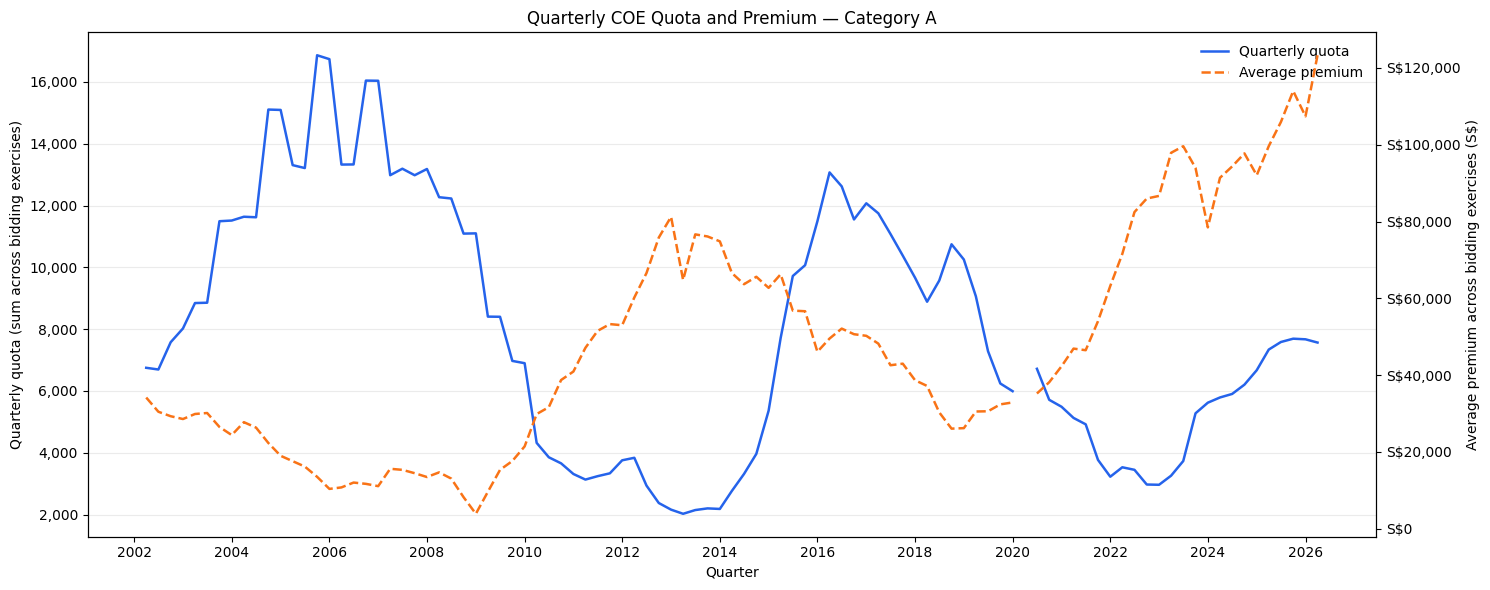

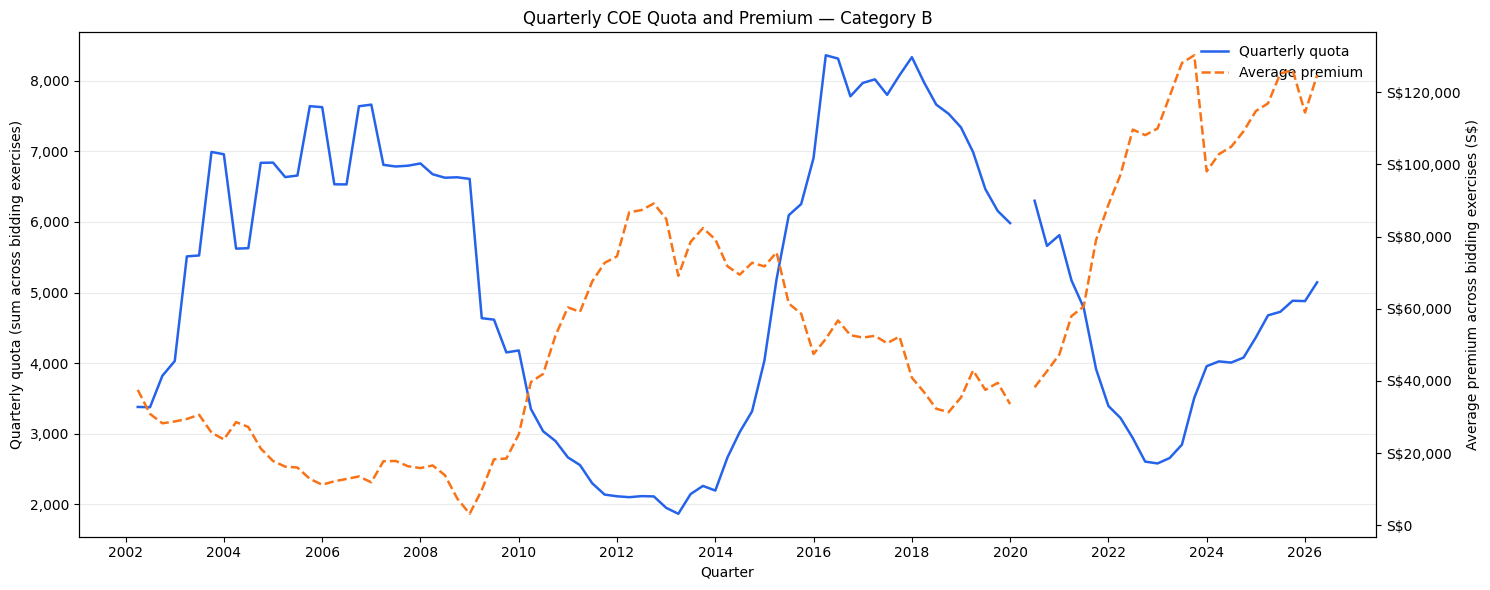

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import matplotlib.dates as mdates

coe_chart_data = coe_quota_quarterly[coe_quota_quarterly["vehicle_class"].isin(["A", "B"])].copy()
coe_chart_data["quarter_date"] = pd.PeriodIndex(year=coe_chart_data["year"], quarter=coe_chart_data["quarter"], freq="Q").to_timestamp()

for vehicle_class in ["A", "B"]:
    data = coe_chart_data.query("vehicle_class == @vehicle_class").sort_values("quarter_date")
    fig, quota_axis = plt.subplots(figsize=(15, 6)); premium_axis = quota_axis.twinx()
    quota_axis.plot(data["quarter_date"], data["quota"], color="#2563EB", linewidth=1.8, label="Quarterly quota")
    premium_axis.plot(data["quarter_date"], data["premium"], color="#F97316", linewidth=1.8, linestyle="--", label="Average premium")
    quota_axis.set(title=f"Quarterly COE Quota and Premium — Category {vehicle_class}", xlabel="Quarter", ylabel="Quarterly quota (sum across bidding exercises)")
    premium_axis.set_ylabel("Average premium across bidding exercises (S$)")
    quota_axis.xaxis.set_major_locator(mdates.YearLocator(2)); quota_axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    quota_axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}")); premium_axis.yaxis.set_major_formatter(StrMethodFormatter("S${x:,.0f}")); quota_axis.grid(axis="y", alpha=.25)
    lines = quota_axis.get_lines() + premium_axis.get_lines(); quota_axis.legend(lines, [line.get_label() for line in lines], frameon=False)
    fig.tight_layout(); plt.show()


In [ ]:
# This simplified model assumes that each category's COE is only affected by its own metrics, eg. category A last quarter premium does not affect category B's premium.
# To focus on model interpretability to find the price elasticity of quotas on price, we will use a regression model that will start with many features, and then use the significance of the coefficient estimate to simplify our model.
# What the desired output will hope to achieve is a equation of the COE price with the increment quota given.

# By looking at the p-value of each feature, I will continue iterating on the model by removing the irrelevant features (p-value > 0.2). As the iteration happens on the backend, the concrete steps will not be displayed in detail. The final output contains only model variables with the significantly correlated features

In [ ]:
# # Naive baseline: log(premium) = intercept + elasticity × log(quota)
# naive_log_log_models, naive_log_log_results = {}, [] #store in dictianary
# for vehicle_class in ["A", "B"]:
#     data = coe_quota_quarterly.query("vehicle_class == @vehicle_class")
#     X_naive = sm.add_constant(np.log(data[["quota"]]).rename(columns={"quota": "log_quota"})); y_naive = np.log(data["premium"])
#     naive_log_log_models[vehicle_class] = sm.OLS(y_naive, X_naive).fit()
#     model = naive_log_log_models[vehicle_class]
#     print(model.summary())
#     predicted = np.exp(model.predict(X_naive))
#     naive_log_log_results.append([vehicle_class, model.params["log_quota"], model.pvalues["log_quota"], model.rsquared, mean_absolute_error(data["premium"], predicted), mean_absolute_percentage_error(data["premium"], predicted) * 100])
# naive_log_log_results = pd.DataFrame(naive_log_log_results, columns=["vehicle_class", "quota_elasticity", "p_value", "r_squared", "mae", "mape_percent"])
# display(naive_log_log_results)


In [ ]:
coe_quota_quarterly = coe_quota_quarterly.drop(columns="_period").dropna().reset_index(drop=True)

In [ ]:
# Full quarterly log model for Category B
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


coe_quota_B_log = coe_quota_quarterly.query("vehicle_class == 'B'").copy()
coe_quota_B_log["increment_quota"] = coe_quota_B_log["quota"] - coe_quota_B_log["quota_lag_q1"]
log_vars = ["premium", "premium_lag_q1", "premium_lag_q2", "premium_lag_q3"]
for col in log_vars: coe_quota_B_log[f"log_{col}"] = np.log(coe_quota_B_log[col])
y_log_B = coe_quota_B_log["log_premium"].astype(float)
X_log_B = coe_quota_B_log[["increment_quota"] + [f"log_{col}" for col in log_vars[1:]]].astype(float)
log_model_B = sm.OLS(y_log_B, X_log_B).fit()
print(log_model_B.summary())
log_pred_B = np.exp(log_model_B.predict(X_log_B))
print(f"MAE: ${mean_absolute_error(coe_quota_B_log['premium'], log_pred_B):,.2f}")
print(f"MAPE: {mean_absolute_percentage_error(coe_quota_B_log['premium'], log_pred_B) * 100:.2f}%")


                                 OLS Regression Results                                
Dep. Variable:            log_premium   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          6.906e+04
Date:                Tue, 01 Sep 2026   Prob (F-statistic):                   7.00e-150
Time:                        00:54:19   Log-Likelihood:                          22.248
No. Observations:                  90   AIC:                                     -36.50
Df Residuals:                      86   BIC:                                     -26.50
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [ ]:
# Full quarterly linear model for Category B
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

coe_quota_B_linear = coe_quota_quarterly.query("vehicle_class == 'B'").copy()
coe_quota_B_linear["increment_quota"] = coe_quota_B_linear["quota"] - coe_quota_B_linear["quota_lag_q1"]
y_linear_B = coe_quota_B_linear["premium"].astype(float)
X_linear_B = coe_quota_B_linear[["increment_quota", "quota_lag_q1", "quota_lag_q2", "premium_lag_q1", "bids_received_lag_q1", "bids_received_lag_q2", "bids_received_lag_q3"]].astype(float)
linear_model_B = sm.OLS(y_linear_B, X_linear_B).fit()
print(linear_model_B.summary())
linear_pred_B = linear_model_B.predict(X_linear_B)
print(f"MAE: ${mean_absolute_error(y_linear_B, linear_pred_B):,.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_linear_B, linear_pred_B) * 100:.2f}%")


                                 OLS Regression Results                                
Dep. Variable:                premium   R-squared (uncentered):                   0.991
Model:                            OLS   Adj. R-squared (uncentered):              0.991
Method:                 Least Squares   F-statistic:                              1346.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):                    1.32e-82
Time:                        00:54:19   Log-Likelihood:                         -914.61
No. Observations:                  90   AIC:                                      1843.
Df Residuals:                      83   BIC:                                      1861.
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [ ]:
#Final model takes the best variables from both log and linear regression to find the best model

In [ ]:
# B final selected log regression
# Selected quarterly log model for Category B
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

coe_quota_B_model = coe_quota_quarterly.query("vehicle_class == 'B'").copy().sort_values(["year", "quarter"])
coe_quota_B_model["increment_quota"] = coe_quota_B_model["quota"] - coe_quota_B_model["quota_lag_q1"]
for col in ["increment_quota","premium", "premium_lag_q1", "premium_lag_q2","premium_lag_q3","bids_received_lag_q1"]: coe_quota_B_model[f"log_{col}"] = np.log(coe_quota_B_model[col])
X_predictB = coe_quota_B_model[["increment_quota", "log_premium_lag_q1"]].astype(float)
y_predict_B = coe_quota_B_model["log_premium"].astype(float)
selected_model_B = sm.OLS(y_predict_B, X_predictB).fit()
print(selected_model_B.summary())


                                 OLS Regression Results                                
Dep. Variable:            log_premium   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.297e+05
Date:                Tue, 01 Sep 2026   Prob (F-statistic):                   2.18e-153
Time:                        00:54:19   Log-Likelihood:                          18.377
No. Observations:                  90   AIC:                                     -32.75
Df Residuals:                      88   BIC:                                     -27.75
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Selected quarterly log model for Category A
import numpy as np
import pandas as pd
import statsmodels.api as sm

coe_quota_A_model = coe_quota_quarterly.query("vehicle_class == 'A'").copy().sort_values(["year", "quarter"])
coe_quota_A_model["increment_quota"] = coe_quota_A_model["quota"] - coe_quota_A_model["quota_lag_q1"]
for col in ["premium", "premium_lag_q1", "premium_lag_q2"]: coe_quota_A_model[f"log_{col}"] = np.log(coe_quota_A_model[col])
X_predictA = coe_quota_A_model[["increment_quota", "log_premium_lag_q1"]].astype(float)
y_predict_A = coe_quota_A_model["log_premium"].astype(float)
selected_model_A = sm.OLS(y_predict_A, X_predictA).fit()
print(selected_model_A.summary())


                                 OLS Regression Results                                
Dep. Variable:            log_premium   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.722e+05
Date:                Tue, 01 Sep 2026   Prob (F-statistic):                   8.39e-159
Time:                        00:54:19   Log-Likelihood:                          32.247
No. Observations:                  90   AIC:                                     -60.49
Df Residuals:                      88   BIC:                                     -55.49
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [ ]:
# This section validates the above model based on training data before test year, with test year starting from 2010. In each year, we will test the absolute difference of the predicted quarterly premium vs the actual, then take mean to get MAPE and MAE
# We repeat the testing for years up to 2026.

In [ ]:
# Validation for model A
quarterly_expanding_results = []
for test_index in coe_quota_A_model.query("year >= 2010").sort_values(["year", "quarter"]).index:
    train = coe_quota_A_model["quarter_number from feb 2002"] < coe_quota_A_model.loc[test_index, "quarter_number from feb 2002"]
    model = sm.OLS(y_predict_A[train], X_predictA[train]).fit(); actual = np.exp(y_predict_A.loc[test_index]); predicted = np.exp(model.predict(X_predictA.loc[[test_index]]).iloc[0])
    quarterly_expanding_results.append([coe_quota_A_model.loc[test_index, "year"], f"Q{coe_quota_A_model.loc[test_index, 'quarter']}", train.sum(), actual, predicted, abs(actual - predicted), abs(actual - predicted) / actual * 100])
quarterly_expanding_results = pd.DataFrame(quarterly_expanding_results, columns=["test_year", "test_quarter", "train_quarters", "actual_premium", "predicted_premium", "absolute_error", "absolute_percentage_error"])
display(quarterly_expanding_results)
# print(quarterly_expanding_results.absolute_percentage_error.min())
# print(quarterly_expanding_results.absolute_percentage_error.max())
print(quarterly_expanding_results.absolute_percentage_error.mean())
print(quarterly_expanding_results.absolute_error.mean())


,test_year,test_quarter,train_quarters,actual_premium,predicted_premium,absolute_error,absolute_percentage_error
0,2010,Q1,28,21420.500000,17309.156399,4111.343601,19.193500
1,2010,Q2,29,29842.166667,24833.211246,5008.955421,16.784825
2,2010,Q3,30,31642.833333,30530.356628,1112.476705,3.515730
3,2010,Q4,31,38713.500000,31820.283178,6893.216822,17.805718
4,2011,Q1,32,40924.666667,39601.888976,1322.777690,3.232226
...,...,...,...,...,...,...,...
57,2025,Q2,85,99642.833333,89431.140740,10211.692593,10.248296
58,2025,Q3,86,105938.166667,99461.357016,6476.809651,6.113764
59,2025,Q4,87,114003.500000,106720.805593,7282.694407,6.388132
60,2026,Q1,88,107406.833333,115832.939609,8426.106276,7.845037


8.313114309132967
4994.843095653786


In [ ]:
# Validation for model B
quarterly_expanding_results = []
for test_index in coe_quota_B_model.query("year >= 2010").sort_values(["year", "quarter"]).index:
    train = coe_quota_B_model["quarter_number from feb 2002"] < coe_quota_B_model.loc[test_index, "quarter_number from feb 2002"]
    model = sm.OLS(y_predict_B[train], X_predictB[train]).fit(); actual = np.exp(y_predict_B.loc[test_index]); predicted = np.exp(model.predict(X_predictB.loc[[test_index]]).iloc[0])
    quarterly_expanding_results.append([coe_quota_B_model.loc[test_index, "year"], f"Q{coe_quota_B_model.loc[test_index, 'quarter']}", train.sum(), actual, predicted, abs(actual - predicted), abs(actual - predicted) / actual * 100])
quarterly_expanding_results = pd.DataFrame(quarterly_expanding_results, columns=["test_year", "test_quarter", "train_quarters", "actual_premium", "predicted_premium", "absolute_error", "absolute_percentage_error"])
display(quarterly_expanding_results)
# print(quarterly_expanding_results.absolute_percentage_error.min())
# print(quarterly_expanding_results.absolute_percentage_error.max())
print(quarterly_expanding_results.absolute_percentage_error.mean())
print(quarterly_expanding_results.absolute_error.mean())


,test_year,test_quarter,train_quarters,actual_premium,predicted_premium,absolute_error,absolute_percentage_error
0,2010,Q1,28,25189.500000,18102.691307,7086.808693,28.133979
1,2010,Q2,29,39669.166667,30188.270330,9480.896337,23.899913
2,2010,Q3,30,41928.666667,43047.387803,1118.721136,2.668153
3,2010,Q4,31,52549.166667,43593.167624,8955.999042,17.043085
4,2011,Q1,32,60367.666667,56251.124283,4116.542384,6.819118
...,...,...,...,...,...,...,...
57,2025,Q2,85,116908.333333,110293.250391,6615.082942,5.658350
58,2025,Q3,86,125165.000000,117736.576397,7428.423603,5.934905
59,2025,Q4,87,126130.333333,123815.574733,2314.758600,1.835212
60,2026,Q1,88,114365.833333,128414.629040,14048.795706,12.284085


9.96617281767354
6541.980674636898


In [ ]:
# This validation technique uses the past quarter data to train the current test year and quarter.

# Category A
# MAPE of about 62 quarter tests = 8.31%
# MAE = $4994
# Category B
# MAPE of about 62 quarter tests = 9.97%
# MAE = $6541


In [ ]:
quota_impact_results = []
for vehicle_class, model, data in [("A", selected_model_A, coe_quota_A_model), ("B", selected_model_B, coe_quota_B_model)]:
    beta = model.params["increment_quota"]
    percent_change = np.exp(beta * 10) - 1
    latest = data.sort_values(["year", "quarter"]).iloc[-1]
    quota_impact_results.append([vehicle_class, beta, percent_change * 100, latest["premium"], latest["premium"] * percent_change, latest["premium"] * (1 + percent_change)])
quota_impact_results = pd.DataFrame(quota_impact_results, columns=["vehicle_class", "increment_quota_coefficient", "price_change_percent_for_10", "latest_premium", "estimated_price_change", "estimated_new_price"])
display(quota_impact_results)

,vehicle_class,increment_quota_coefficient,price_change_percent_for_10,latest_premium,estimated_price_change,estimated_new_price
0,A,-0.000060,-0.059606,123314.166667,-73.503128,123240.663539
1,B,-0.000175,-0.174658,124704.833333,-217.807014,124487.026319


/var/folders/sg/mkdkhr1577j5fnwtbrttp52r0000gn/T/ipykernel_18655/984750517.py:7: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  results["date"] = pd.PeriodIndex(year=results["year"], quarter=results["quarter"], freq="Q").to_timestamp()


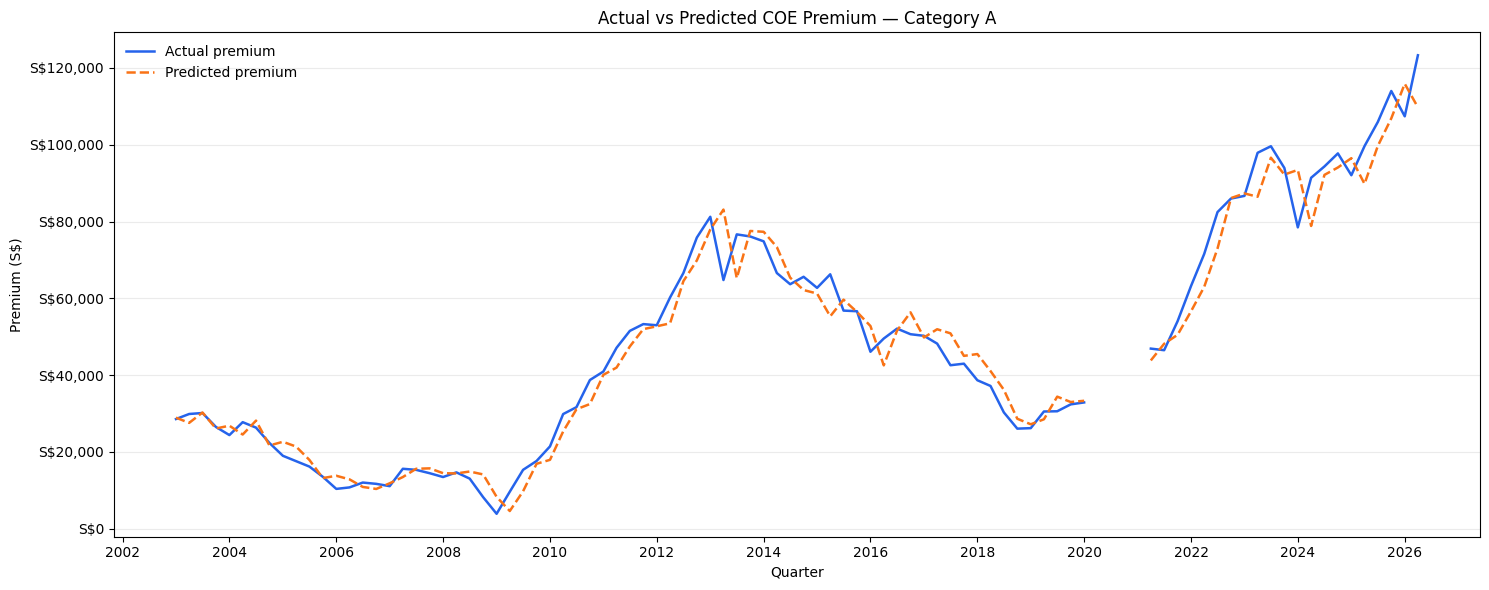

/var/folders/sg/mkdkhr1577j5fnwtbrttp52r0000gn/T/ipykernel_18655/984750517.py:7: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  results["date"] = pd.PeriodIndex(year=results["year"], quarter=results["quarter"], freq="Q").to_timestamp()


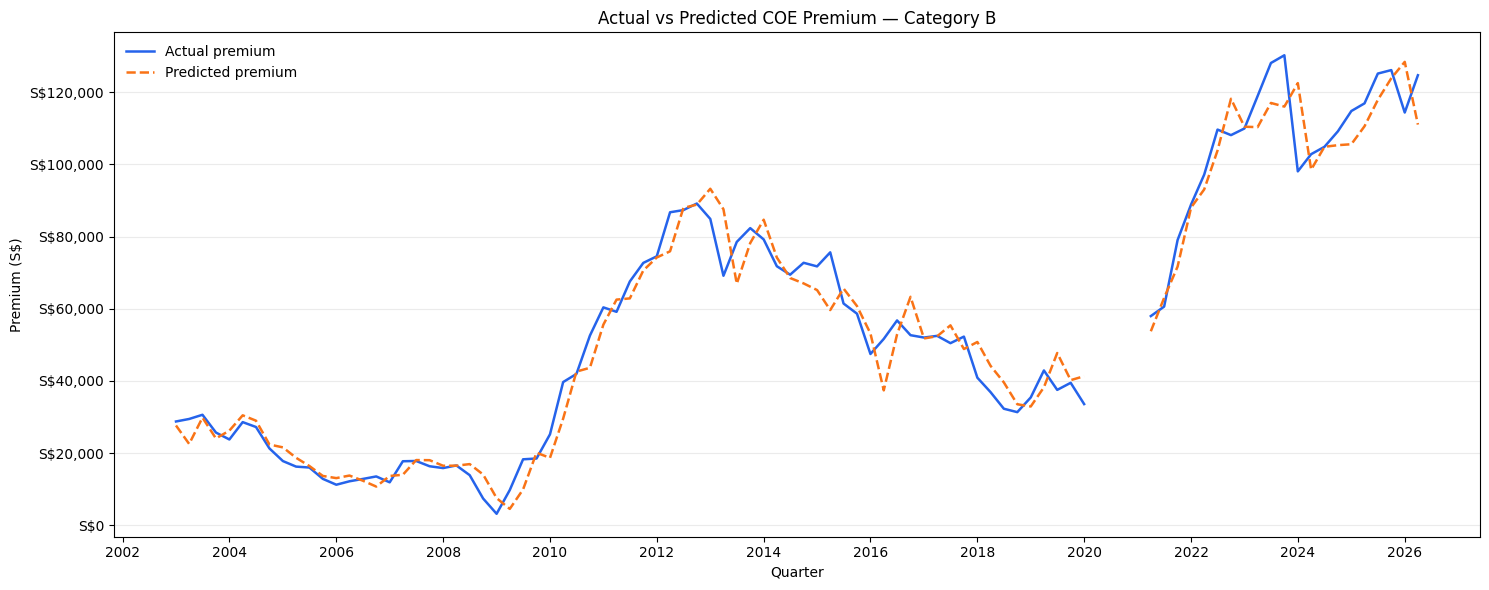

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter

for vehicle_class, data, X, y, model in [("A", coe_quota_A_model, X_predictA, y_predict_A, selected_model_A), ("B", coe_quota_B_model, X_predictB, y_predict_B, selected_model_B)]:
    results = data.loc[X.index, ["year", "quarter"]].copy()
    results["date"] = pd.PeriodIndex(year=results["year"], quarter=results["quarter"], freq="Q").to_timestamp()
    results["actual"], results["predicted"] = np.exp(y), np.exp(model.predict(X))
    # Reindex to every calendar quarter so missing COVID periods remain visible as gaps.
    results = results.set_index("date").reindex(pd.date_range(results["date"].min(), results["date"].max(), freq="QS")).rename_axis("date").reset_index()
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(results["date"], results["actual"], color="#2563EB", linewidth=1.8, label="Actual premium")
    ax.plot(results["date"], results["predicted"], color="#F97316", linewidth=1.8, linestyle="--", label="Predicted premium")
    ax.set(title=f"Actual vs Predicted COE Premium — Category {vehicle_class}", xlabel="Quarter", ylabel="Premium (S$)")
    ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y")); ax.yaxis.set_major_formatter(StrMethodFormatter("S${x:,.0f}"))
    ax.grid(axis="y", alpha=.25); ax.legend(frameon=False); fig.tight_layout(); plt.show()
